# Exercise 2 — Sampling from discrete distributions

In [1]:
%matplotlib inline
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, geom

rng = np.random.default_rng(2026)
plt.rcParams["figure.figsize"] = (10, 4)
N = 10_000


def chisq_gof(observed, expected_probs, n):
    e = n * np.asarray(expected_probs)
    T = np.sum((observed - e) ** 2 / e)
    return dict(stat=float(T), df=len(e) - 1, p=float(chi2.sf(T, len(e) - 1)))

## Part 1 — Geometric(p):  X = floor(log U / log(1-p)) + 1

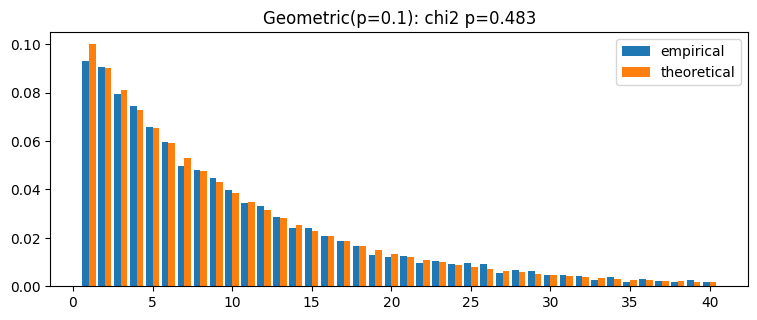

p=0.1: chi2=50.77 df=51 p=0.483 | mean 10.197 (1/p=10.000) var 93.779 (theory 90.000)


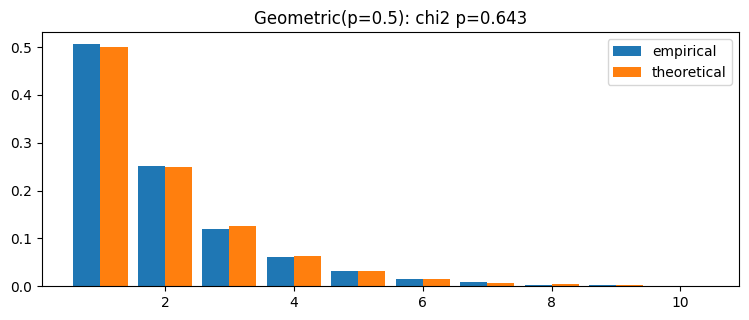

p=0.5: chi2=7.85 df=10 p=0.643 | mean 1.980 (1/p=2.000) var 1.934 (theory 2.000)


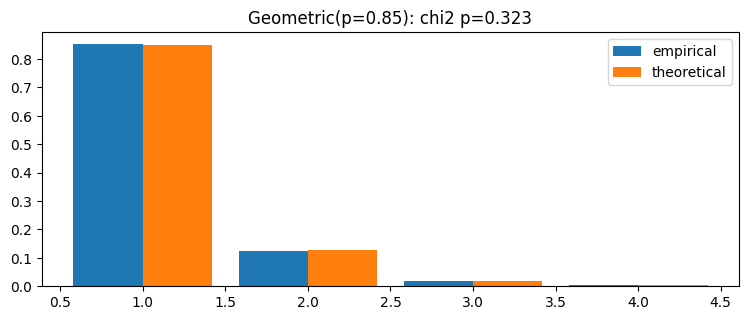

p=0.85: chi2=4.67 df=4 p=0.323 | mean 1.176 (1/p=1.176) var 0.213 (theory 0.208)


In [2]:
def geometric_sample(n, p, rng):
    U = 1.0 - rng.random(n)
    return np.floor(np.log(U) / np.log(1 - p)).astype(int) + 1


def geometric_gof(samples, p, min_expected=5):
    n = len(samples); L = 1
    while n * (1 - p) ** L * p >= min_expected:
        L += 1
    ks = np.arange(1, L + 1)
    probs = (1 - p) ** (ks - 1) * p
    probs = np.append(probs, 1 - probs.sum())
    obs = np.array([np.sum(samples == k) for k in ks] + [np.sum(samples > L)])
    return chisq_gof(obs, probs, n)


for p in [0.1, 0.5, 0.85]:                       # small / moderate / large
    s = geometric_sample(N, p, rng)
    gof = geometric_gof(s, p)
    kmax = min(int(s.max()), int(geom.ppf(0.999, p)), 40)
    ks = np.arange(1, kmax + 1)
    plt.figure(figsize=(9, 3.3)); w = 0.42
    plt.bar(ks - w / 2, [np.mean(s == k) for k in ks], width=w, label="empirical")
    plt.bar(ks + w / 2, (1 - p) ** (ks - 1) * p, width=w, label="theoretical")
    plt.title(f"Geometric(p={p}): chi2 p={gof['p']:.3f}"); plt.legend(); plt.show()
    print(f"p={p}: chi2={gof['stat']:.2f} df={gof['df']} p={gof['p']:.3f} | "
          f"mean {s.mean():.3f} (1/p={1/p:.3f}) var {s.var():.3f} (theory {(1-p)/p**2:.3f})")

## Part 2 — Six-point distribution via direct, rejection, alias

P(X) = (7/48, 5/48, 1/8, 1/16, 1/4, 5/16) for x = 1..6

In [ ]:
x_vals = np.array([1, 2, 3, 4, 5, 6])
p_target = np.array([7, 5, 6, 3, 12, 15]) / 48
assert np.isclose(p_target.sum(), 1.0)


def direct_crude(n, p, x, rng): # cumulative-interval search (binary)
    P = np.cumsum(p)
    return x[np.searchsorted(P, rng.random(n), side="left")]


def rejection_sample(n, p, x, rng): # c = max p_i
    k = len(p); c = p.max()
    out = np.empty(n, dtype=int); filled = trials = 0
    while filled < n:
        m = n - filled
        I = rng.integers(0, k, size=m); U2 = rng.random(m)
        acc = U2 <= p[I] / c; na = int(acc.sum())
        out[filled:filled + na] = x[I[acc]]; filled += na; trials += m
    return out, trials


def build_alias(p): # Vose construction
    k = len(p); prob = np.zeros(k); alias = np.zeros(k, dtype=int)
    scaled = np.array(p) * k
    small = [i for i in range(k) if scaled[i] < 1]
    large = [i for i in range(k) if scaled[i] >= 1]
    while small and large:
        s = small.pop(); l = large.pop()
        prob[s] = scaled[s]; alias[s] = l
        scaled[l] -= (1 - scaled[s])
        (small if scaled[l] < 1 else large).append(l)
    for i in large + small:
        prob[i] = 1.0
    return prob, alias


def alias_sample(n, prob, alias, rng):
    col = rng.integers(0, len(prob), size=n)
    return np.where(rng.random(n) < prob[col], col, alias[col])

direct    chi2= 8.58 df=5 p=0.127 counts=[1491, 1079, 1223, 675, 2482, 3050]
rejection chi2= 3.45 df=5 p=0.631 counts=[1511, 1047, 1243, 643, 2482, 3074]
alias     chi2= 1.24 df=5 p=0.941 counts=[1446, 1027, 1252, 615, 2488, 3172]
rejection trials/draw = 1.860 (theory k*c = 1.875)


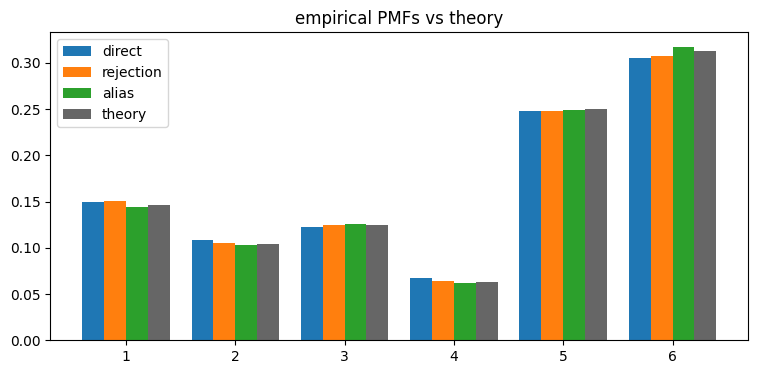

In [4]:
prob_tab, alias_tab = build_alias(p_target)
s_direct = direct_crude(N, p_target, x_vals, rng)
s_reject, n_trials = rejection_sample(N, p_target, x_vals, rng)
s_alias = x_vals[alias_sample(N, prob_tab, alias_tab, rng)]

for name, s in [("direct", s_direct), ("rejection", s_reject), ("alias", s_alias)]:
    obs = np.array([np.sum(s == xi) for xi in x_vals])
    r = chisq_gof(obs, p_target, N)
    print(f"{name:9s} chi2={r['stat']:5.2f} df={r['df']} p={r['p']:.3f} counts={obs.tolist()}")
print(f"rejection trials/draw = {n_trials / N:.3f} (theory k*c = {len(p_target)*p_target.max():.3f})")

w = 0.2
plt.figure(figsize=(9, 4))
plt.bar(x_vals - 1.5 * w, [np.mean(s_direct == xi) for xi in x_vals], width=w, label="direct")
plt.bar(x_vals - 0.5 * w, [np.mean(s_reject == xi) for xi in x_vals], width=w, label="rejection")
plt.bar(x_vals + 0.5 * w, [np.mean(s_alias == xi) for xi in x_vals], width=w, label="alias")
plt.bar(x_vals + 1.5 * w, p_target, width=w, color="black", alpha=0.6, label="theory")
plt.legend(); plt.title("empirical PMFs vs theory"); plt.show()

## Part 3 — Performance comparison

In [5]:
def best_time(fn, repeats=5):
    return min((lambda t0=time.perf_counter(): (fn(), time.perf_counter() - t0)[1])()
               for _ in range(repeats))

Nbig = 500_000
P = np.cumsum(p_target); prob_tab, alias_tab = build_alias(p_target)
t_setup = {"direct": best_time(lambda: np.cumsum(p_target)),
           "rejection": best_time(lambda: p_target.max()),
           "alias": best_time(lambda: build_alias(p_target))}
t_draw = {"direct": best_time(lambda: x_vals[np.searchsorted(P, rng.random(Nbig), "left")]),
          "rejection": best_time(lambda: rejection_sample(Nbig, p_target, x_vals, rng)),
          "alias": best_time(lambda: alias_sample(Nbig, prob_tab, alias_tab, rng))}
print(f"{'method':10s}{'setup (ms)':>12s}{'draw '+str(Nbig)+' (ms)':>18s}")
for m in ("direct", "rejection", "alias"):
    print(f"{m:10s}{t_setup[m]*1e3:12.4f}{t_draw[m]*1e3:18.3f}")

method      setup (ms)  draw 500000 (ms)
direct          0.0013            12.438
rejection       0.0010            16.882
alias           0.0055             5.778


## Part 4 — Recommendations

| Method | Setup | Per draw | Notes |
|---|---|---|---|
| Direct (crude) | O(k) cumsum | O(log k) binary search | simple, exact, no rejection |
| Rejection | O(k) | O(k·c) expected | easy; slow for peaked p (large c) |
| Alias | O(k) tables | O(1) | fastest per draw; best for many draws from a fixed p |

- **Inverse transform / direct**: when the CDF inverts (geometric) or k is small.
- **Rejection**: quick code, near-uniform probabilities.
- **Alias**: many samples from a fixed distribution (preprocessing amortised by O(1) draws).